In [ ]:
import pandas as pd
import numpy as np
import json
import os

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    precision_recall_curve,
    average_precision_score,
)
import seaborn as sns
import matplotlib.pyplot as plt

from pathlib import Path
import sys


PROJECT_ROOT = Path.cwd().parent
sys.path.append(str(PROJECT_ROOT))

In [ ]:
def load_and_split_csv(
    csv_path,
    target_col="is_fraud",
    test_size=0.2,
    random_state=42,
):
    df = pd.read_csv(csv_path)

    if target_col not in df.columns:
        raise ValueError(f"Target column '{target_col}' not found. Columns: {df.columns.tolist()}")

    X = df.drop(columns=[target_col])
    y = df[target_col].astype(int)

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=random_state, stratify=y
    )
    return X_train, y_train, X_test, y_test


In [ ]:
def keep_categoricals_as_is(X_train, X_test, categorical_cols):
    X_train = X_train.copy()
    X_test = X_test.copy()
    for c in categorical_cols:
        X_train[c] = X_train[c].astype(str)
        X_test[c] = X_test[c].astype(str)
    return X_train, X_test


In [ ]:
def no_smote(X_train, y_train):
    return X_train, y_train


In [ ]:
class SimpleRIPPERClassifier:
    def __init__(
        self,
        max_rules=50,
        max_conditions_per_rule=4,
        min_rule_coverage=20,
        min_rule_precision=0.03,
        n_numeric_thresholds=20,
        prune_fraction=0.20,
        random_state=42,
        laplace=1.0,
    ):
        self.max_rules = max_rules
        self.max_conditions_per_rule = max_conditions_per_rule
        self.min_rule_coverage = min_rule_coverage
        self.min_rule_precision = min_rule_precision
        self.n_numeric_thresholds = n_numeric_thresholds
        self.prune_fraction = prune_fraction
        self.random_state = random_state
        self.laplace = laplace

        self.rules_ = []
        self.default_p_ = None
        self.threshold_ = 0.5
        self.feature_names_ = None

    # Condition helpers
    @staticmethod
    def _is_categorical(series):
        return series.dtype == "object" or str(series.dtype).startswith("category")

    @staticmethod
    def _apply_condition(X, cond):
        col = cond["col"]
        op = cond["op"]
        val = cond["val"]
        if op == "==":
            return (X[col].astype(str).values == str(val))
        if op == "<=":
            return (X[col].values <= val)
        if op == ">":
            return (X[col].values > val)
        raise ValueError(f"Unknown op: {op}")

    def _apply_rule(self, X, conds):
        mask = np.ones(len(X), dtype=bool)
        for cond in conds:
            mask &= self._apply_condition(X, cond)
            if not mask.any():
                break
        return mask

    # Candidate generation
    def _candidate_conditions(self, X, y):
      conds = []
      y = np.asarray(y).astype(int)

      for col in X.columns:
        s = X[col]

        if self._is_categorical(s):
            # Build a small table: category (count, fraud_rate)
            tmp = pd.DataFrame({"cat": s.astype(str).values, "y": y})
            stats = tmp.groupby("cat")["y"].agg(["count", "mean"]).sort_values("mean", ascending=False)

            min_cat_support = max(50, int(0.0005 * len(s)))
            stats = stats[stats["count"] >= min_cat_support]

            # Top categories by fraud rate
            top_k = 300
            cats = stats.head(top_k).index.tolist()

            for cat in cats:
                conds.append({"col": col, "op": "==", "val": cat})

        else:
            vals = s.values.astype(float)
            if np.nanmin(vals) == np.nanmax(vals):
                continue
            qs = np.linspace(0.05, 0.95, self.n_numeric_thresholds)
            thresholds = np.unique(np.nanquantile(vals, qs))
            for t in thresholds:
                t = float(t)
                conds.append({"col": col, "op": "<=", "val": t})
                conds.append({"col": col, "op": ">", "val": t})

      return conds

    #  Rule growing and pruning
    def _best_next_condition(self, Xg, yg, current_conds, used_cols, forbidden_cols=None):
        if forbidden_cols is None:
            forbidden_cols = set()
        base_mask = self._apply_rule(Xg, current_conds)
        if base_mask.sum() == 0:
            return None

        base_y = yg[base_mask]
        base_tp = int((base_y == 1).sum())
        base_fp = int((base_y == 0).sum())
        base_prec = base_tp / (base_tp + base_fp) if (base_tp + base_fp) else 0.0

        best = None
        best_score = base_prec

        for cond in self._all_conds_:
            if cond["col"] in used_cols or cond["col"] in forbidden_cols:
                continue
            mask = base_mask & self._apply_condition(Xg, cond)
            cov = int(mask.sum())
            if cov < self.min_rule_coverage:
                continue

            covered_y = yg[mask]
            tp = int((covered_y == 1).sum())
            fp = int((covered_y == 0).sum())
            if tp == 0:
                continue

            prec = tp / (tp + fp)
            score = prec + 1e-6 * cov

            if score > best_score:
                best_score = score
                best = cond

        return best

    def _grow_rule(self, Xg, yg, forbidden_cols=None):
        if forbidden_cols is None:
            forbidden_cols = set()
        conds = []
        used_cols = set()

        for _ in range(self.max_conditions_per_rule):
            next_cond = self._best_next_condition(Xg, yg, conds, used_cols, forbidden_cols)
            if next_cond is None:
                break

            conds.append(next_cond)
            used_cols.add(next_cond["col"])

            mask = self._apply_rule(Xg, conds)
            if mask.sum() < self.min_rule_coverage:
                break

            covered_y = yg[mask]
            tp = int((covered_y == 1).sum())
            fp = int((covered_y == 0).sum())
            prec = tp / (tp + fp) if (tp + fp) else 0.0

            if prec >= max(self.min_rule_precision, 0.90):
                break

        return conds

    def _prune_rule(self, Xp, yp, conds):
        def f1_for(c):
            mask = self._apply_rule(Xp, c)
            if mask.sum() == 0:
                return 0.0
            yhat = np.zeros(len(yp), dtype=int)
            yhat[mask] = 1
            tp = int(((yhat == 1) & (yp == 1)).sum())
            fp = int(((yhat == 1) & (yp == 0)).sum())
            fn = int(((yhat == 0) & (yp == 1)).sum())
            prec = tp / (tp + fp) if (tp + fp) else 0.0
            rec = tp / (tp + fn) if (prec + fn) else 0.0
            return (2 * prec * rec / (prec + rec)) if (prec + rec) else 0.0

        best_conds = conds
        best_f1 = f1_for(best_conds)

        for new_len in range(len(conds) - 1, 0, -1):
            cand = conds[:new_len]
            f1 = f1_for(cand)
            if f1 >= best_f1:
                best_f1 = f1
                best_conds = cand

        return best_conds

    def _best_threshold_f1(self, y_true, p):
        cand = np.unique(p)
        if len(cand) > 200:
            cand = np.quantile(p, np.linspace(0.0, 1.0, 200))
        best_t, best_f1 = 0.5, -1.0
        for t in cand:
            yhat = (p >= t).astype(int)
            tp = int(((yhat == 1) & (y_true == 1)).sum())
            fp = int(((yhat == 1) & (y_true == 0)).sum())
            fn = int(((yhat == 0) & (y_true == 1)).sum())
            prec = tp / (tp + fp) if (tp + fp) else 0.0
            rec = tp / (tp + fn) if (tp + fn) else 0.0
            f1 = (2 * prec * rec / (prec + rec)) if (prec + rec) else 0.0
            if f1 > best_f1:
                best_f1 = f1
                best_t = float(t)
        return best_t

    # Fitting and Predicting
    def fit(self, X, y):
        X = X.copy()
        y = np.asarray(y).astype(int)

        self.feature_names_ = list(X.columns)
        self.default_p_ = float(y.mean())

        self._all_conds_ = self._candidate_conditions(X, y)


        X_grow, X_prune, y_grow, y_prune = train_test_split(
            X, y,
            test_size=self.prune_fraction,
            random_state=self.random_state,
            stratify=y
        )

        remaining_mask = np.ones(len(X_grow), dtype=bool)
        rules = []
        used_cols_global = set()

        fails = 0
        max_fails = 5

        for _ in range(self.max_rules):
            if (y_grow[remaining_mask] == 1).sum() < self.min_rule_coverage:
                break

            Xg = X_grow.loc[remaining_mask]
            yg = y_grow[remaining_mask]

            conds = self._grow_rule(Xg, yg, forbidden_cols=used_cols_global)
            if len(conds) == 0:
                fails += 1
                if fails >= max_fails:
                    break
                continue

            # Pruning
            conds = self._prune_rule(X_prune, y_prune, conds)
            # Preventing pathological pruning
            if len(conds) == 0:
                fails += 1
                if fails >= max_fails:
                    break
                continue

            # Evaluating candidate rule
            cover_mask = self._apply_rule(Xg, conds)
            cov = int(cover_mask.sum())
            if cov < self.min_rule_coverage:
                fails += 1
                if fails >= max_fails:
                    break
                continue

            covered_y = yg[cover_mask]
            tp = int((covered_y == 1).sum())
            fp = int((covered_y == 0).sum())
            prec = tp / (tp + fp) if (tp + fp) else 0.0
            if prec < self.min_rule_precision:
                fails += 1
                if fails >= max_fails:
                    break
                continue

            fails = 0
            p_rule = (tp + self.laplace) / (tp + fp + 2 * self.laplace)
            rules.append({
                "conds": conds,
                "p": float(p_rule),
                "tp": tp,
                "fp": fp,
                "coverage": cov
            })

            for c in conds:
                used_cols_global.add(c["col"])

            idx_to_remove = Xg.index.values[cover_mask]
            remove_mask = X_grow.index.isin(idx_to_remove)
            remaining_mask = remaining_mask & (~remove_mask)

        self.rules_ = rules

        # Choosing probability threshold on the prune set
        p_prune = self.predict_proba(X_prune)[:, 1]
        self.threshold_ = self._best_threshold_f1(y_prune, p_prune)

        return self

    def predict_proba(self, X):
        X = X.copy()
        n = len(X)
        proba = np.full(n, self.default_p_, dtype=float)

        for rule in self.rules_:
            mask = self._apply_rule(X, rule["conds"])
            unassigned = (proba == self.default_p_)
            assign = mask & unassigned
            proba[assign] = rule["p"]

        proba = np.clip(proba, 0.0, 1.0)
        return np.vstack([1 - proba, proba]).T

    def predict(self, X):
        p = self.predict_proba(X)[:, 1]
        return (p >= self.threshold_).astype(int)

    def get_rules_text(self, max_rules=20):
        lines = []
        for i, rule in enumerate(self.rules_[:max_rules], start=1):
            parts = []
            for c in rule["conds"]:
                if c["op"] == "==":
                    parts.append(f"{c['col']} == {repr(str(c['val']))}")
                else:
                    parts.append(f"{c['col']} {c['op']} {c['val']:.6g}")
            cond_txt = " AND ".join(parts) if parts else "(TRUE)"
            lines.append(
                f"Rule {i}: IF {cond_txt} THEN fraud (p\u2248{rule['p']:.3f}, cov={rule['coverage']}, tp={rule['tp']}, fp={rule['fp']})"
            )
        if not lines:
            return "No rules learned; model defaults to base rate."
        lines.append(f"DEFAULT: not fraud (base_rate\u2248{self.default_p_:.4f})")
        lines.append(f"(predict threshold chosen on prune set: {self.threshold_:.3f})")
        return "\n".join(lines)


In [ ]:
def evaluate_and_save_results(model, X_test, y_test, json_path="evaluation_results.json"):
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    # Metrics
    report = classification_report(y_test, y_pred, output_dict=True)
    roc_auc = roc_auc_score(y_test, y_prob)
    avg_precision = average_precision_score(y_test, y_prob)

    # ROC Curve
    fpr, tpr, roc_thresholds = roc_curve(y_test, y_prob)

     # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)

    # Precision-Recall Curve
    precision, recall, pr_thresholds = precision_recall_curve(y_test, y_prob)

    results = {
        "classification_report": report,
        "roc_auc": roc_auc,
        "average_precision": avg_precision,
        "confusion_matrix": {
            "labels": ["non_fraud", "fraud"],
            "matrix": cm.tolist()
        },
        "roc_curve": {
            "fpr": fpr.tolist(),
            "tpr": tpr.tolist(),
            "thresholds": roc_thresholds.tolist()
        },
        "precision_recall_curve": {
            "precision": precision.tolist(),
            "recall": recall.tolist(),
            "thresholds": pr_thresholds.tolist()
        }
    }

    with open(json_path, "w") as f:
        json.dump(results, f, indent=4)

    return results


In [ ]:
DATA_PATH = PROJECT_ROOT/"Data Understanding, Exploration & Feature Engineering/Dataset & Feature Engineered data/transactions_pre_processed.csv"
if not os.path.exists(DATA_PATH):
    DATA_PATH = "transactions_pre_processed.csv"

X_train, y_train, X_test, y_test = load_and_split_csv(DATA_PATH, target_col="is_fraud")
X_train.shape, X_test.shape, y_train.mean(), y_test.mean()


((239756, 21),
 (59939, 21),
 np.float64(0.02206409850014181),
 np.float64(0.022055756685964063))

In [ ]:
# Categorical columns
cat_cols = X_train.select_dtypes(include='object').columns.tolist()
cat_cols


['country', 'bin_country', 'merchant_category']

In [ ]:
# Categoricals as raw strings
X_train_pre, X_test_pre = keep_categoricals_as_is(X_train, X_test, cat_cols)

# Skipping SMOTE for rule-learning to preserve interpretability
X_train_final, y_train_final = no_smote(X_train_pre, y_train)

# Verifying class balance
y_train.value_counts(), y_train_final.value_counts()


(is_fraud
 0    234466
 1      5290
 Name: count, dtype: int64,
 is_fraud
 0    234466
 1      5290
 Name: count, dtype: int64)

In [ ]:
# Training RIPPER-style rule-set model
ripper_model = SimpleRIPPERClassifier(
    max_rules=50,
    max_conditions_per_rule=4,
    min_rule_coverage=20,
    min_rule_precision=0.04,
    n_numeric_thresholds=20,
    prune_fraction=0.20,
    random_state=42,
    laplace=1.0,
)

ripper_model.fit(X_train_final, y_train_final)

print(ripper_model.get_rules_text(max_rules=20))

#  Business lift diagnostics
base = float(y_train.mean())
rule_p = float(ripper_model.rules_[0]["p"]) if len(ripper_model.rules_) > 0 else float("nan")

print("Base fraud rate (train):", base)
print("Rule fraud rate (when rule fires):", rule_p)
print("Lift (rule_p / base):", rule_p / base if base > 0 else float("nan"))


Rule 1: IF account_age_days <= 149 THEN fraud (p≈0.208, cov=9641, tp=2008, fp=7633)
DEFAULT: not fraud (base_rate≈0.0221)
(predict threshold chosen on prune set: 0.208)
Base fraud rate (train): 0.02206409850014181
Rule fraud rate (when rule fires): 0.20833765425697398
Lift (rule_p / base): 9.442382350479216


In [ ]:
print("Num rules learned:", len(ripper_model.rules_))
print(ripper_model.get_rules_text())

Num rules learned: 1
Rule 1: IF account_age_days <= 149 THEN fraud (p≈0.208, cov=9641, tp=2008, fp=7633)
DEFAULT: not fraud (base_rate≈0.0221)
(predict threshold chosen on prune set: 0.208)


In [ ]:
JSON_PATH = "results/ripper_model_evaluation.json"

results = evaluate_and_save_results(
    ripper_model,
    X_test_pre,
    y_test,
    json_path=JSON_PATH
)

results["classification_report"]


{'0': {'precision': 0.9883571642132292,
  'recall': 0.9587150485354078,
  'f1-score': 0.9733104714399529,
  'support': 58617.0},
 '1': {'precision': 0.21428571428571427,
  'recall': 0.49924357034795763,
  'f1-score': 0.29986369831894594,
  'support': 1322.0},
 'accuracy': 0.9485810574083652,
 'macro avg': {'precision': 0.6013214392494717,
  'recall': 0.7289793094416828,
  'f1-score': 0.6365870848794494,
  'support': 59939.0},
 'weighted avg': {'precision': 0.9712844326560766,
  'recall': 0.9485810574083652,
  'f1-score': 0.9584570932710483,
  'support': 59939.0}}

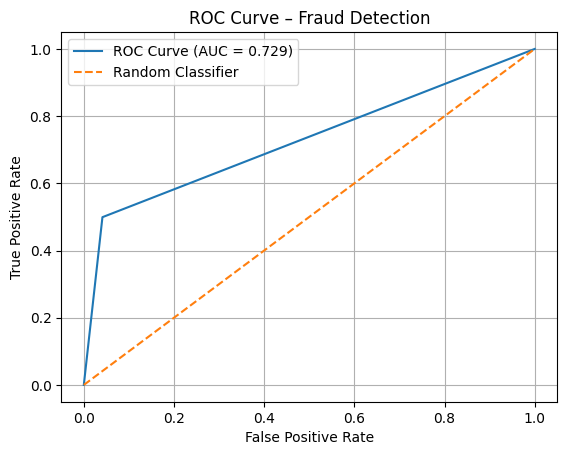

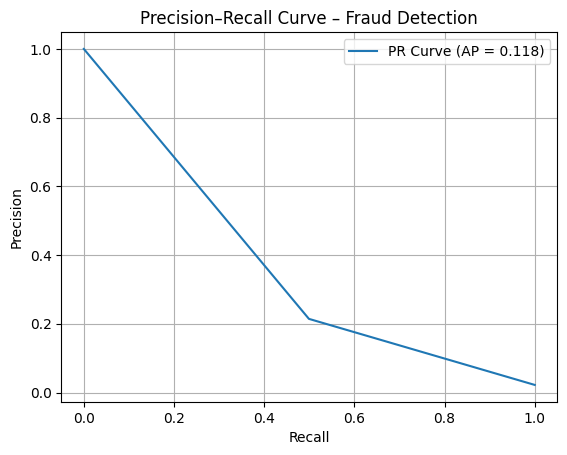

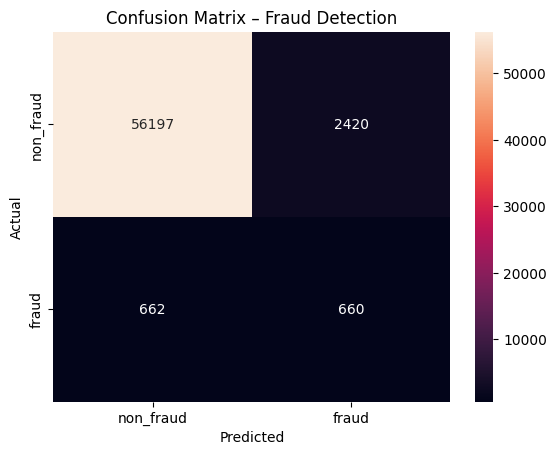

In [ ]:
# Extract Evalution Results

# ROC Curve
fpr = results["roc_curve"]["fpr"]
tpr = results["roc_curve"]["tpr"]
roc_auc = results["roc_auc"]

plt.figure()
plt.plot(fpr, tpr, label=f"ROC Curve (AUC = {roc_auc:.3f})")
plt.plot([0, 1], [0, 1], linestyle='--', label='Random Classifier')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve – Fraud Detection")
plt.legend()
plt.grid(True)
plt.show()

# PR Curve
precision = results["precision_recall_curve"]["precision"]
recall = results["precision_recall_curve"]["recall"]
avg_precision = results["average_precision"]

plt.figure()
plt.plot(recall, precision, label=f"PR Curve (AP = {avg_precision:.3f})")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curve – Fraud Detection")
plt.legend()
plt.grid(True)
plt.show()

# Confusion Matrix
cm = np.array(results["confusion_matrix"]["matrix"])
labels = results["confusion_matrix"]["labels"]

plt.figure()
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=labels,
            yticklabels=labels)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix – Fraud Detection")
plt.show()